<a href="https://colab.research.google.com/github/lkostenko/KMA/blob/main/test_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##User LTV

In [83]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [68]:
df = pd.read_excel('/content/Data Analyst Test Task Data new – Kostenko.xlsx', sheet_name='Tasks 1-2')

In [69]:
df

,uuid,event_timestamp,event_name,product_id,is_trial,period,trial_period,revenue_usd,transaction_id,refunded_transaction_id
0,0001feb9-ec8e-4f53-83c8-a829bbbe1838,2023-05-18 22:16:16,trial,weekly.2.49,False,7,0,0.00,e99b4003-7bb9-4cbe-a585-e8a103b0e3cb,NaN
1,0001feb9-ec8e-4f53-83c8-a829bbbe1838,2023-05-18 22:25:56,cancellation,weekly.2.49,False,7,0,0.00,dc4e828a-f365-46e4-90ef-bb2785379d1a,NaN
2,00026e14-e302-4772-b691-8b0e67ab0c32,2023-05-30 07:10:37,trial,weekly.2.49,False,7,0,0.00,b585adc7-f22a-4cd4-b863-2eb256d697b4,NaN
3,00026e14-e302-4772-b691-8b0e67ab0c32,2023-06-05 23:10:44,purchase,weekly.2.49,False,7,0,2.49,b672df8a-fcb2-4737-8a5f-98a85b183609,NaN
4,00026e14-e302-4772-b691-8b0e67ab0c32,2023-06-12 23:10:57,purchase,weekly.2.49,False,7,0,2.49,33254b74-1437-4eb1-a71d-be3c0958bdf8,NaN
...,...,...,...,...,...,...,...,...,...,...
36000,fff4e985-c2a2-4f74-b639-b5ffb8d09caa,2023-03-06 15:13:28,cancellation,weekly.4.99.3d.trial,True,7,3,0.00,0c09dd3d-4abb-4eac-884f-4a97d91f1f1b,NaN
36001,fff6db2b-b529-4866-b36b-c39eeeda5b0e,2023-03-04 16:25:41,trial,weekly.4.99.3d.trial,True,7,3,0.00,8baf6e43-0822-4e89-9392-b6b0450fdddf,NaN
36002,fff6db2b-b529-4866-b36b-c39eeeda5b0e,2023-03-04 16:41:31,cancellation,weekly.4.99.3d.trial,True,7,3,0.00,d3d83615-c66c-4c91-9e56-d684e8fd9992,NaN
36003,fffa3afd-8b47-4821-bfbd-804adef8731f,2023-05-09 00:25:58,trial,monthly.9.99.3d.trial,True,30,3,0.00,e00a0ef1-2d6e-46c5-904c-ee71739da85d,NaN


In [70]:
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'])

In [72]:
refunds = df[df['event_name'] == 'refund'][['refunded_transaction_id', 'revenue_usd']]
refunds.columns = ['transaction_id', 'refund_amount']

purchases = df[df['event_name'] == 'purchase'].copy()
purchases = purchases.merge(refunds, on='transaction_id', how='left')
purchases['net_revenue'] = purchases['revenue_usd'] + purchases['refund_amount'].fillna(0)

first_payments = purchases[purchases['net_revenue'] > 0].groupby('uuid')['event_timestamp'].min().reset_index()
first_payments.columns = ['uuid', 'cohort_start_time']

df_actual = purchases.merge(first_payments, on='uuid', how='inner')



In [73]:
def get_actual_ltv(data, period='W'):
    temp = data.copy()
    if period == 'W':
        # Тижневі когорти
        temp['cohort'] = temp['cohort_start_time'].dt.to_period('W').apply(lambda r: r.start_time)
        temp['age'] = ((temp['event_timestamp'] - temp['cohort_start_time']).dt.days // 7).astype(int)
    else:
        # Місячні когорти
        temp['cohort'] = temp['cohort_start_time'].dt.to_period('M').apply(lambda r: r.start_time)
        temp['age'] = ((temp['event_timestamp'] - temp['cohort_start_time']).dt.days // 30).astype(int)

    temp = temp[temp['age'] >= 0]

    cohort_sizes = temp.groupby('cohort')['uuid'].nunique().reset_index()
    cohort_sizes.columns = ['cohort', 'cohort_size']

    revenue_per_age = temp.groupby(['cohort', 'age'])['net_revenue'].sum().reset_index()

    revenue_per_age = revenue_per_age.sort_values(['cohort', 'age'])
    revenue_per_age['cum_revenue'] = revenue_per_age.groupby('cohort')['net_revenue'].cumsum()

    ltv_results = revenue_per_age.merge(cohort_sizes, on='cohort')
    ltv_results['actual_ltv'] = ltv_results['cum_revenue'] / ltv_results['cohort_size']

    return ltv_results[['cohort', 'age', 'actual_ltv', 'cohort_size']]


In [74]:
weekly_ltv = get_actual_ltv(df_actual, 'W')
monthly_ltv = get_actual_ltv(df_actual, 'M')


In [75]:
weekly_ltv

,cohort,age,actual_ltv,cohort_size
0,2023-02-27,0,5.489571,44
1,2023-02-27,1,7.358662,44
2,2023-02-27,2,8.322071,44
3,2023-02-27,3,9.492497,44
4,2023-02-27,4,11.359665,44
...,...,...,...,...
617,2023-10-02,1,8.488000,5
618,2023-10-02,4,10.486000,5
619,2023-10-09,0,7.490000,3
620,2023-10-16,0,9.990000,1


In [76]:
monthly_ltv

,cohort,age,actual_ltv,cohort_size
0,2023-03-01,0,10.778917,734
1,2023-03-01,1,18.522325,734
2,2023-03-01,2,23.971245,734
3,2023-03-01,3,28.569527,734
4,2023-03-01,4,31.928657,734
5,2023-03-01,5,34.276774,734
6,2023-03-01,6,36.237639,734
7,2023-03-01,7,37.246642,734
8,2023-03-01,8,37.348699,734
9,2023-04-01,0,11.282568,528


In [78]:
def plot_ltv_curves(ltv_df, title, xlabel):
    plt.figure(figsize=(12, 6))

    cohorts = sorted(ltv_df['cohort'].unique())

    for cohort in cohorts:
        cohort_data = ltv_df[ltv_df['cohort'] == cohort].sort_values('age')
        label_date = pd.to_datetime(cohort).strftime('%Y-%m-%d')
        plt.plot(cohort_data['age'], cohort_data['actual_ltv'], marker='.', label=label_date)

    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Cumulative LTV ($)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.legend(title='Cohorts', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

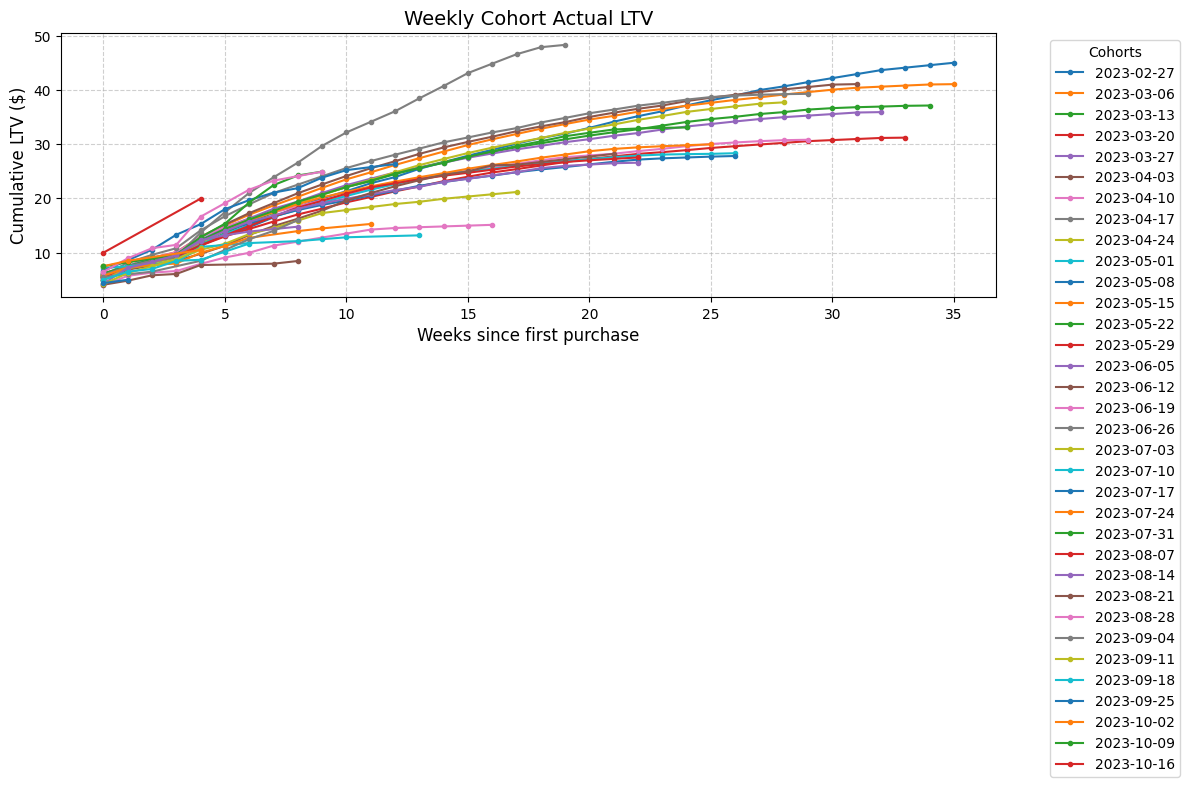

In [79]:
plot_ltv_curves(weekly_ltv, 'Weekly Cohort Actual LTV', 'Weeks since first purchase')

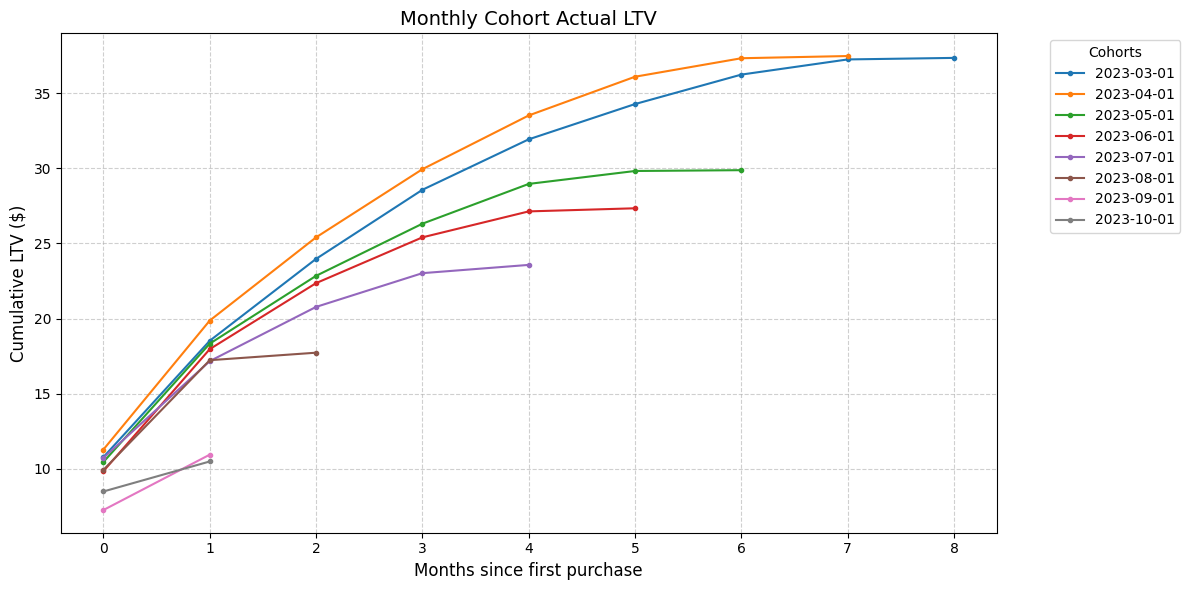

In [80]:
plot_ltv_curves(monthly_ltv, 'Monthly Cohort Actual LTV', 'Months since first purchase')

### Висновок

Криві LTV для більшості когорт мають класичну форму степеневої залежності. Найбільший приріст доходу відбувається в перші 4 тижні (для тижневих когорт) або перші 2 місяці для місячних.

Початкова якість користувачів у квітні була вищою, ніж у березні. Проте стабільність нахилу кривих для обох місяців схожа, що вказує на однакову ефективність ретеншену в  додатку.